## Notebook Description


Introduction

This notebook presents the exploratory data analysis (EDA) conducted on the original Amazon Reviews dataset, which contains approximately 64GB of product review data across multiple categories.

Due to the size and complexity of the dataset, the primary objective of this analysis is to understand the overall structure, quality, and patterns within the data before further processing and modelling. The analysis helps the team identify important characteristics such as review distribution, product activity, language patterns, and potential data issues.

To efficiently analyse such a large dataset, tools such as DuckDB and Parquet data handling are used to query and process the data without loading the entire dataset into memory.

The key goals of this notebook include:
- Understanding the structure and schema of the dataset.
- Exploring review distributions and product activity
- Examining text characteristics and language patterns.
- Identifying data quality issues such as missing values or inconsistencies.
- Generating insights that guide feature engineering and dataset reduction

The insights obtained from this exploratory analysis inform the next stage of the project, where a smaller and more manageable subset of the data is created for deeper analysis and modelling.

In [5]:
# Install necessary libraries
%pip install spacy

!python -m spacy download en_core_web_sm

%pip install fasttext

Note: you may need to restart the kernel to use updated packages.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 38.2 MB/s  0:00:00eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
Note: you may need to restart the kernel to use updated packages.


In [6]:
#Load Neccessary Libraries
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib
from pathlib import Path
import fasttext
import os

In [30]:
# Download the FastText language identification model

#Check if the model already exists
model_path = "lid.176.bin"
if not os.path.exists(model_path):
    #Download manually using wget
    import urllib.request
    print("Downloading FastText language ID model...")
    url = "https://dl.fbaipublicfiles.com/fasttext/supervised-models/lid.176.bin"
    urllib.request.urlretrieve(url, model_path)
    print("Download complete!")

#Load the model
lang_model = fasttext.load_model(model_path)
print("FastText model loaded successfully!")

FastText model loaded successfully!


In [7]:
# Establish the file path to the Parquet file

FILE = "alexa_reviews.parquet"

# Create a DuckDB connection
con = duckdb.connect(database=":memory:")


In [8]:

def check_file(file_path=FILE):
    """
    Pcheck if the csv file exists and preview the data.
    Includes error handling for file access and SQL execution.
    """  
    con = None

    try:
        # check if file exists
        file_path = Path(file_path)
        if not file_path.is_file():
            raise FileNotFoundError(f"File not found: {file_path}")
        
        # connect to duckdb
        con = duckdb.connect(database=":memory:")
        
        # preview first few rows of the dataset
        preview = con.execute(f"""
            SELECT * 
            FROM '{file_path}'
            LIMIT 5
        """).fetchdf()
        return preview
    
    except FileNotFoundError as e:
        print(f"Error: {e}")
        
    except duckdb.Error as e:
        print(f"DuckDB Error: {e}")
        
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

# Call the function to check the file and preview the data
check_file("alexa_reviews.parquet")   
        

,asin,reviewerID,reviewerName,overall,summary,reviewText,unixReviewTime,reviewTime,verified,vote
0,B017O9P72A,A27BTSGLXK2C5K,Jacob M. Wessler,1.0,"VERY Buggy, doesn't work.",Alexa is not able to control my lights. If I a...,1449792000,"12 11, 2015",False,None
1,B017O9P72A,A27ZJ1NCBFP1HZ,Greg,4.0,So Far So Good,"Alexa works great for me so far, but I'm also ...",1449532800,"12 8, 2015",False,5
2,B017O9P72A,ACCQIOZMFN4UK,Da-Gr8-1,1.0,Time waster,Weak!!\n\nAlexa doesn't even recognize the nam...,1449446400,"12 7, 2015",False,11
3,B017O9P72A,A3KUPJ396OQF78,Larry Russlin,2.0,Buggy,Can only control one of two bulbs from one of ...,1449273600,"12 5, 2015",False,None
4,B017O9P72A,A1U1RE1ZI19E1H,Rebekah,1.0,stopped working,this worked great then randomly stopped. pleas...,1517529600,"02 2, 2018",False,2


In [9]:
# view the data schema
con.execute(f"DESCRIBE SELECT * FROM '{FILE}' LIMIT 0").fetchdf()

,column_name,column_type,null,key,default,extra
0,asin,VARCHAR,YES,None,None,None
1,reviewerID,VARCHAR,YES,None,None,None
2,reviewerName,VARCHAR,YES,None,None,None
3,overall,DOUBLE,YES,None,None,None
4,summary,VARCHAR,YES,None,None,None
5,reviewText,VARCHAR,YES,None,None,None
6,unixReviewTime,BIGINT,YES,None,None,None
7,reviewTime,VARCHAR,YES,None,None,None
8,verified,BOOLEAN,YES,None,None,None
9,vote,VARCHAR,YES,None,None,None


In [10]:
#Check the total number of rows in the dataset
row_count = con.execute(f"""
            SELECT COUNT(*) AS total_rows
            FROM '{FILE}'
            """).fetchdf()
row_count

,total_rows
0,233055327


The dataset contains **233,055,327 rows**, meaning there are 233 million reviews in total. 

This large size shows the need to use **DuckDB** to query and analyze the data efficiently, rather than loading the entire dataset into memory with pandas.

## Reviewer behaviour Analysis

In [11]:
reviews_per_reviewer = con.execute(f"""SELECT reviewerID, COUNT(*) AS review_count
FROM "{FILE}"
GROUP BY reviewerID
ORDER BY review_count DESC
LIMIT 20;
""").fetchdf()
reviews_per_reviewer

,reviewerID,review_count
0,A328S9RN3U5M68,13446
1,A2OJW07GQRNJUT,9837
2,A2F6N60Z96CAJI,9169
3,AHUT55E980RDR,7521
4,A1D2C0WDCSHUWZ,7088
5,A9Q28YTLYREO7,6934
6,A3MV1KKHX51FYT,5835
7,A13QTZ8CIMHHG4,5317
8,A1JLU5H1CCENWX,5248
9,A2EDZH51XHFA9B,5122


In [12]:
sample_reviewer = con.execute(f"""
SELECT reviewerID
FROM "{FILE}"
GROUP BY reviewerID
HAVING COUNT(*) > 1
LIMIT 1
""").fetchone()[0]

print(f"Showing review history for reviewerID: {sample_reviewer}")

# Fetch all reviews for this reviewer
review_history = con.execute(f"""
SELECT
    reviewerID,
    asin,
    unixReviewTime,
    reviewText,
    reviewTime,
    verified
FROM "{FILE}"
WHERE reviewerID = '{sample_reviewer}'
ORDER BY unixReviewTime
""").df()
# Shift unixReviewTime to get next review timestamp
review_history['next_review_time'] = review_history['unixReviewTime'].shift(-1)
review_history['time_diff_seconds'] = review_history['next_review_time'] - review_history['unixReviewTime']
review_history['time_diff_days'] = review_history['time_diff_seconds'] / 86400

# Flag rapid reviews posted within 1 day
review_history['rapid_post_flag'] = review_history['time_diff_days'] < 1

# Display results
print("Reviewer activity across multiple products with time differences and rapid posting flag:")
display(review_history)

Showing review history for reviewerID: A116NWR2IICCXD
Reviewer activity across multiple products with time differences and rapid posting flag:


,reviewerID,asin,unixReviewTime,reviewText,reviewTime,verified,next_review_time,time_diff_seconds,time_diff_days,rapid_post_flag
0,A116NWR2IICCXD,B00DVGGWAM,1461801600,Nice,"04 28, 2016",True,1.461802e+09,0.0,0.0,True
1,A116NWR2IICCXD,B00RRKFZTM,1461801600,It shows very nice worth the $6 ships fast as ...,"04 28, 2016",True,1.463875e+09,2073600.0,24.0,False
2,A116NWR2IICCXD,B0158D2VJ6,1463875200,A bit too big.,"05 22, 2016",True,1.463875e+09,0.0,0.0,True
3,A116NWR2IICCXD,B01C8T77DS,1463875200,Good quality,"05 22, 2016",True,1.463875e+09,0.0,0.0,True
4,A116NWR2IICCXD,B00OC6WR22,1463875200,very good chargers my HTC fast,"05 22, 2016",True,1.467504e+09,3628800.0,42.0,False
5,A116NWR2IICCXD,B01EGVJM84,1467504000,Very good case. You cant go wrong!,"07 3, 2016",True,1.467504e+09,0.0,0.0,True
6,A116NWR2IICCXD,B0183IV0NQ,1467504000,It's okay,"07 3, 2016",True,1.467504e+09,0.0,0.0,True
7,A116NWR2IICCXD,B00ZSYGB2E,1467504000,Has a nice feel to it.\nFits Perfect!,"07 3, 2016",True,1.467504e+09,0.0,0.0,True
8,A116NWR2IICCXD,B01DTBRBQW,1467504000,great! Would buy again!,"07 3, 2016",True,1.471478e+09,3974400.0,46.0,False
9,A116NWR2IICCXD,B00UNMORN6,1471478400,everyone finds it funny.\nGREAT!!! Would buy a...,"08 18, 2016",False,1.474070e+09,2592000.0,30.0,False


The above depicts a review burst pattern by examining time differences, date, and the rapid post flag.
However, this cannot be confirmed until further investigation is conducted on duplicate values, as what appears to be unusual behaviour could be due to duplicates.

## Duplicate check

In [13]:
duplicates_count = con.execute(f"""
SELECT COUNT(*) AS total_duplicates
FROM (
    SELECT *, COUNT(*) OVER(PARTITION BY asin, reviewerID) AS count
    FROM '{FILE}'
) sub
WHERE count > 1
""").fetchdf()

duplicates_count

,total_duplicates
0,9223348


In [14]:
dinstinct_text = con.execute(f"""SELECT asin, reviewerID,
       COUNT(DISTINCT reviewText) AS distinct_texts,
       COUNT(*) AS total_rows
FROM '{FILE}'
GROUP BY asin, reviewerID
HAVING COUNT(*) > 1
ORDER BY total_rows DESC
LIMIT 50;
""").fetchdf()

dinstinct_text

,asin,reviewerID,distinct_texts,total_rows
0,B001MQA3DU,A18VOU6GQHXGO0,1,212
1,B001MQA3DU,A3EBCNHNQIP2Z3,1,212
2,B001MQA3DU,A3J4XZKYUNBX8N,1,212
3,B001MQA3DU,A161OJ95SYSN7A,1,212
4,B001MQA3DU,A2EBCZL8BD0YJG,1,212
5,B001MQA3DU,APBSTR99CVE5,1,212
6,B001MQA3DU,A28N1WH94B2QQG,1,212
7,B001MQA3DU,APEYDZ2CAA6OL,1,212
8,B001MQA3DU,A805WWXUO79RP,1,212
9,B001MQA3DU,A2YXRT2XIJIO57,1,212


In [15]:
review_sample1 = con.execute(f"""
SELECT *
FROM '{FILE}'
WHERE asin = 'B001MQA3DU'
  AND reviewerID = 'A805WWXUO79RP'
ORDER BY reviewTime
LIMIT 10;
""").fetchdf()

review_sample1

,asin,reviewerID,reviewerName,overall,summary,reviewText,unixReviewTime,reviewTime,verified,vote
0,B001MQA3DU,A805WWXUO79RP,Cameron Campbell,1.0,Mistakes Throughout,"From the first two pagers and on, phrases or w...",1497571200,"06 16, 2017",True,4
1,B001MQA3DU,A805WWXUO79RP,Cameron Campbell,1.0,Mistakes Throughout,"From the first two pagers and on, phrases or w...",1497571200,"06 16, 2017",True,4
2,B001MQA3DU,A805WWXUO79RP,Cameron Campbell,1.0,Mistakes Throughout,"From the first two pagers and on, phrases or w...",1497571200,"06 16, 2017",True,4
3,B001MQA3DU,A805WWXUO79RP,Cameron Campbell,1.0,Mistakes Throughout,"From the first two pagers and on, phrases or w...",1497571200,"06 16, 2017",True,4
4,B001MQA3DU,A805WWXUO79RP,Cameron Campbell,1.0,Mistakes Throughout,"From the first two pagers and on, phrases or w...",1497571200,"06 16, 2017",True,4
5,B001MQA3DU,A805WWXUO79RP,Cameron Campbell,1.0,Mistakes Throughout,"From the first two pagers and on, phrases or w...",1497571200,"06 16, 2017",True,4
6,B001MQA3DU,A805WWXUO79RP,Cameron Campbell,1.0,Mistakes Throughout,"From the first two pagers and on, phrases or w...",1497571200,"06 16, 2017",True,4
7,B001MQA3DU,A805WWXUO79RP,Cameron Campbell,1.0,Mistakes Throughout,"From the first two pagers and on, phrases or w...",1497571200,"06 16, 2017",True,4
8,B001MQA3DU,A805WWXUO79RP,Cameron Campbell,1.0,Mistakes Throughout,"From the first two pagers and on, phrases or w...",1497571200,"06 16, 2017",True,4
9,B001MQA3DU,A805WWXUO79RP,Cameron Campbell,1.0,Mistakes Throughout,"From the first two pagers and on, phrases or w...",1497571200,"06 16, 2017",True,4


In [16]:
review_sample2 = con.execute(f"""
SELECT *
FROM '{FILE}'
WHERE asin = 'B001MQA3DU'
  AND reviewerID = 'APBSTR99CVE5'
ORDER BY reviewTime
LIMIT 10;
""").fetchdf()

review_sample2

,asin,reviewerID,reviewerName,overall,summary,reviewText,unixReviewTime,reviewTime,verified,vote
0,B001MQA3DU,APBSTR99CVE5,Mark Johnston,2.0,Typos galore,Not a review of the book because I haven't bee...,1496880000,"06 8, 2017",True,6
1,B001MQA3DU,APBSTR99CVE5,Mark Johnston,2.0,Typos galore,Not a review of the book because I haven't bee...,1496880000,"06 8, 2017",True,6
2,B001MQA3DU,APBSTR99CVE5,Mark Johnston,2.0,Typos galore,Not a review of the book because I haven't bee...,1496880000,"06 8, 2017",True,6
3,B001MQA3DU,APBSTR99CVE5,Mark Johnston,2.0,Typos galore,Not a review of the book because I haven't bee...,1496880000,"06 8, 2017",True,6
4,B001MQA3DU,APBSTR99CVE5,Mark Johnston,2.0,Typos galore,Not a review of the book because I haven't bee...,1496880000,"06 8, 2017",True,6
5,B001MQA3DU,APBSTR99CVE5,Mark Johnston,2.0,Typos galore,Not a review of the book because I haven't bee...,1496880000,"06 8, 2017",True,6
6,B001MQA3DU,APBSTR99CVE5,Mark Johnston,2.0,Typos galore,Not a review of the book because I haven't bee...,1496880000,"06 8, 2017",True,6
7,B001MQA3DU,APBSTR99CVE5,Mark Johnston,2.0,Typos galore,Not a review of the book because I haven't bee...,1496880000,"06 8, 2017",True,6
8,B001MQA3DU,APBSTR99CVE5,Mark Johnston,2.0,Typos galore,Not a review of the book because I haven't bee...,1496880000,"06 8, 2017",True,6
9,B001MQA3DU,APBSTR99CVE5,Mark Johnston,2.0,Typos galore,Not a review of the book because I haven't bee...,1496880000,"06 8, 2017",True,6


In [17]:
review_sample3 = con.execute(f"""
SELECT *
FROM '{FILE}'
WHERE asin = '0553212737'
  AND reviewerID = 'A1D2C0WDCSHUWZ'
ORDER BY reviewTime
LIMIT 10;
""").fetchdf()

review_sample3

,asin,reviewerID,reviewerName,overall,summary,reviewText,unixReviewTime,reviewTime,verified,vote
0,0553212737,A1D2C0WDCSHUWZ,E. A. Solinas,5.0,The sensible and the sensitive,"One of the Dashwood daughters is smart, down-t...",1262304000,"01 1, 2010",False,None
1,0553212737,A1D2C0WDCSHUWZ,E. A. Solinas,5.0,Let other pens dwell on guilt and misery,Jane Austen. Her name is practically synonymou...,1262304000,"01 1, 2010",False,3
2,0553212737,A1D2C0WDCSHUWZ,E. A. Solinas,5.0,The sensible and the sensitive,"One of the Dashwood daughters is smart, down-t...",1263254400,"01 12, 2010",False,None
3,0553212737,A1D2C0WDCSHUWZ,E. A. Solinas,5.0,Let other pens dwell on guilt and misery,Jane Austen. Her name is practically synonymou...,1263427200,"01 14, 2010",False,None
4,0553212737,A1D2C0WDCSHUWZ,E. A. Solinas,5.0,It's such a happiness...,"""Emma Woodhouse, handsome, clever, and rich, w...",1295136000,"01 16, 2011",False,5
5,0553212737,A1D2C0WDCSHUWZ,E. A. Solinas,5.0,When a young lady is to be a heroine,Gothic romances were all the rage in the late ...,1421539200,"01 18, 2015",False,None
6,0553212737,A1D2C0WDCSHUWZ,E. A. Solinas,5.0,The sensible and the sensitive,"One of the Dashwood daughters is smart, down-t...",1263859200,"01 19, 2010",False,None
7,0553212737,A1D2C0WDCSHUWZ,E. A. Solinas,5.0,It's such a happiness when good people get tog...,"""Emma Woodhouse, handsome, clever, and rich, w...",1264464000,"01 26, 2010",False,None
8,0553212737,A1D2C0WDCSHUWZ,E. A. Solinas,5.0,A second,"In Jane Austen's time, young women were taught...",1420329600,"01 4, 2015",False,None
9,0553212737,A1D2C0WDCSHUWZ,E. A. Solinas,5.0,It's such a happiness when good people get tog...,"""Emma Woodhouse, handsome, clever, and rich, w...",1262649600,"01 5, 2010",False,None


In [18]:
review_sample4 = con.execute(f"""
SELECT *
FROM '{FILE}'
WHERE asin = 'B00CYZC5S4'
  AND reviewerID = 'A2TXR85WQLE32N'
ORDER BY reviewTime
LIMIT 10;
""").fetchdf()

review_sample4

,asin,reviewerID,reviewerName,overall,summary,reviewText,unixReviewTime,reviewTime,verified,vote
0,B00CYZC5S4,A2TXR85WQLE32N,HMS Warspite,5.0,More stories about Anne of Green Gables's home...,"Lucy Maud Montgomery, author of the famous ""An...",1484784000,"01 19, 2017",True,None
1,B00CYZC5S4,A2TXR85WQLE32N,HMS Warspite,5.0,The story of a red-haired orphan...,"Once upon a time, a young orphan arrived at a ...",1390521600,"01 24, 2014",True,None
2,B00CYZC5S4,A2TXR85WQLE32N,HMS Warspite,5.0,Fit for your library...,This particular version of L.M. Montgomery's s...,1357344000,"01 5, 2013",True,4
3,B00CYZC5S4,A2TXR85WQLE32N,HMS Warspite,5.0,Love finds Anne Shirley...,"At eighteen, the fiesty and independent Anne S...",1360540800,"02 11, 2013",True,None
4,B00CYZC5S4,A2TXR85WQLE32N,HMS Warspite,5.0,Love finds Anne Shirley...,"""Anne of the Island"" is the wonderful third no...",1360800000,"02 14, 2013",True,None
5,B00CYZC5S4,A2TXR85WQLE32N,HMS Warspite,5.0,More about Anne's home town...,"Lucy Maud Montgomery, author of the famous ""An...",1424908800,"02 26, 2015",True,None
6,B00CYZC5S4,A2TXR85WQLE32N,HMS Warspite,5.0,A decision of the heart...,Canadian author Lucy Maud Montgomery wrote a s...,1360022400,"02 5, 2013",True,None
7,B00CYZC5S4,A2TXR85WQLE32N,HMS Warspite,5.0,Anne of Redmond College...,"""Anne of the Island"" is the third of Lucy Maud...",1391558400,"02 5, 2014",True,None
8,B00CYZC5S4,A2TXR85WQLE32N,HMS Warspite,5.0,Anne tries teaching...,"""Anne of Avonlea"" is the sequel to Lucy Maud M...",1360108800,"02 6, 2013",True,None
9,B00CYZC5S4,A2TXR85WQLE32N,HMS Warspite,5.0,A girl with imagination...,Once upon a time in Canada's Prince Edward Isl...,1391644800,"02 6, 2014",True,None


Diiferent review sample was done to see if there is a consistent pattern in the data leading to review burst.
This will be further validated when the data has been cleaned.

## Missing Values Analysis

In [19]:
#check total number of missing values
missing_values = con.execute(f"""
SELECT
    SUM(CASE WHEN asin IS NULL THEN 1 ELSE 0 END) AS missing_asin,
    SUM(CASE WHEN reviewerID IS NULL THEN 1 ELSE 0 END) AS missing_reviewerID,
    SUM(CASE WHEN reviewerName IS NULL THEN 1 ELSE 0 END) AS missing_reviewerName,
    SUM(CASE WHEN overall IS NULL THEN 1 ELSE 0 END) AS missing_overall,
    SUM(CASE WHEN reviewText IS NULL THEN 1 ELSE 0 END) AS missing_reviewText,
    SUM(CASE WHEN vote IS NULL THEN 1 ELSE 0 END) AS missing_vote,
    SUM(CASE WHEN verified IS NULL THEN 1 ELSE 0 END) AS missing_verified,
    SUM(CASE WHEN reviewTime IS NULL THEN 1 ELSE 0 END) AS missing_reviewTime,
    SUM(CASE WHEN unixReviewTime IS NULL THEN 1 ELSE 0 END) AS missing_unixReviewTime
FROM "{FILE}"
""").fetchdf()

missing_values

,missing_asin,missing_reviewerID,missing_reviewerName,missing_overall,missing_reviewText,missing_vote,missing_verified,missing_reviewTime,missing_unixReviewTime
0,0.0,0.0,13133.0,0.0,153384.0,200464287.0,0.0,0.0,0.0


A missing values check was performed across all columns of the dataset, which contains **233,055,327 reviews**. Here is the detailed interpretation:

- **asin (Product ID)** : Zero missing values.  
  Every review has a valid product ID, which is essential for linking reviews to products. 

- **reviewerID (Reviewer ID)** :Zero missing values.  
  Each review has a unique reviewer ID, allowing us to track reviewer activity. 

- **reviewerName** : 13,133 missing values.  
  A very small portion of reviews do not have a reviewer name. Since this is negligible, we may decide to leave them as is or drop/flag for downstream tasks.  

- **overall(Rating)**: Zero missing values.  
  All reviews have a rating score, which is critical for sentiment analysis. 

- **reviewText** :153,384 missing values.  
  A small fraction of reviews have no text. Depending on the task, these rows could be dropped (for text-based sentiment analysis) or flagged.  

- **vote** :200,464,287 missing values.  
  Most reviews have no vote. This is expected because not all reviews receive user votes. For analysis, we can impute missing votes as `0` instead of dropping them.  

- **verified (Verified Purchase)** : Zero missing values.  
  Every review has a verified purchase status, allowing filtering for genuine purchases. 

- **reviewTime and unixReviewTime** :Zero missing values.  
  All reviews have timestamps, which are necessary for time-based analysis or modeling. 

**Key Takeaways:**  
1. Critical columns (asin, reviewerID, overall, verified, reviewTime) are complete.  
2. Minor missing data (reviewerName, reviewText) can be handled depending on the analysis.  
3. The vote column has many missing values, but imputing with 0 ensures no data loss and maintains reproducibility.

## Verified purchase Analysis

In [20]:
# Analsye the number of verified purchases and non verified purchases
verified_purchases = con.execute(f"""
SELECT
    verified,
    COUNT(*) AS review_count
FROM "{FILE}"
GROUP BY verified
""").fetchdf()

verified_purchases

,verified,review_count
0,True,195918627
1,False,37136700


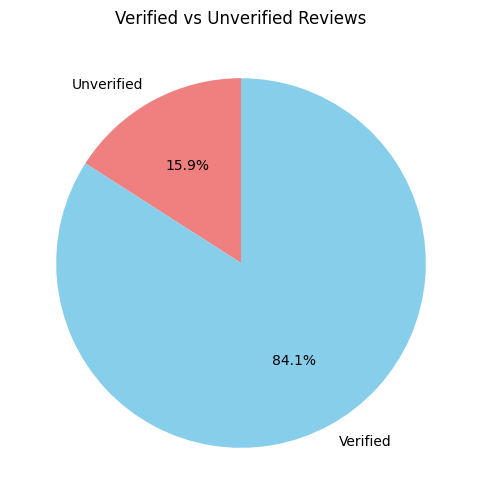

In [21]:
#visaulise the verified purchase distribution

verified_purchase_counts= [37136700, 195918627]
labels = ['Unverified', 'Verified']

plt.figure(figsize=(6,6))
plt.pie(verified_purchase_counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=['lightcoral', 'skyblue'])
plt.title("Verified vs Unverified Reviews")
plt.show()

Majority of the reviews are verified:
- About 196M reviews are from verified purchases.
- This is good indication as verified reviews are generally more reliable.

Unverified reviews:
- Around 37M reviews are unverified.
- These reviews might be flagged during the suspicious reviews ML analysis.

In [22]:
average_verification_ratings = con.execute(f"""SELECT verified, AVG(overall) AS avg_rating
FROM "{FILE}"
GROUP BY verified;
""").fetchdf()

average_verification_ratings

,verified,avg_rating
0,False,4.150403
1,True,4.247693


The average rating for verified purchases is (4.25) is slightly higher than for unverified reviews (4.15). 

This suggests that verified customers tend to provide more positive feedback. 

However, the difference is marginal, indicating that unverified reviews do not drastically deviate from verified ones at an aggregate level

## Summary statistics of the Numeric Columns

In [23]:
#Check summary staitiscs for the overall rating
ratings_summary = con.execute(f"""
        SELECT 
            AVG(overall) AS avg_overall,
            MIN(overall) AS min_overall,
            MAX(overall) AS max_overall
        FROM read_parquet('{FILE}')
    """).fetchdf()
ratings_summary

,avg_overall,min_overall,max_overall
0,4.23219,0.0,5.0


avg_overall = 4.23219 
   - On average, reviewers gave the products about 4.23 stars.
   
min_overall = 0.0
   - The lowest rating in the dataset is 0 stars.

max_overall = 5.0
   - The highest rating is 5 stars.

In [24]:
# Summary statistics of the Votes

votes_summary = con.execute(f"""
        SELECT
            COUNT(TRY_CAST(vote AS BIGINT)) AS numeric_votes,
            AVG(TRY_CAST(vote AS BIGINT))   AS avg_vote,
            MIN(TRY_CAST(vote AS BIGINT))   AS min_vote,
            MAX(TRY_CAST(vote AS BIGINT))   AS max_vote
        FROM read_parquet('{FILE}')
    """).fetchdf()
votes_summary


,numeric_votes,avg_vote,min_vote,max_vote
0,32587701,7.527312,2,999



numeric_votes = 32,587,701 
 - Out of all reviews, 32.5 million votes were valid numbers. The rest were probably missing, empty, or non-numeric.

avg_vote = 7.53
 - On average, each review that had a numeric vote received about 7–8 helpful votes.

min_vote = 2
 - The smallest number of votes a review got was 2.

max_vote = 999
- The highest number of votes a review received was 999.

From the data schema:
- vote is stored as a VARCHAR.
- This means the column contains text, not numbers.   
   - So some entries might be like "5", "12", or even "N/A", "unknown", or empty strings.

- TRY_CAST(vote AS BIGINT)tries to turn the text into a number:
	-	"5" = 5 
	-	"12" = 12 
	-	"N/A" = NULL (ignored in calculations, so it doesn’t crash the query)

- Without TRY_CAST, DuckDB would fail when it sees non-numeric text. With it, only the clean numeric votes are counted in COUNT, AVG, MIN, and MAX


## Categorical Column analysis

In [25]:
# Query to count total number of unique reviewers

reviewer_count = con.execute(f"""
SELECT COUNT(DISTINCT reviewerID) AS total_reviewers
FROM read_parquet('{FILE}')
""").fetchdf()
reviewer_count

,total_reviewers
0,43531850


The dataset has 43,531,850 unique reviewers.

 - Every reviewer is counted only once, even if they wrote multiple reviews.
 
- So while the dataset might have more total reviews, these come from about 43.5 million different people.

- This indicates a very diverse set of users, not dominated by just a few reviewers.

In [26]:
# check the length of the review text in characters
review_length = con.execute(f"""
        SELECT 
            AVG(LENGTH(reviewText)) AS avg_len,
            MIN(LENGTH(reviewText)) AS min_len,
            MAX(LENGTH(reviewText)) AS max_len
        FROM read_parquet('{FILE}')
    """).fetchdf()

review_length

,avg_len,min_len,max_len
0,275.815981,1,35094


These numbers describe the length of the review text in characters:

avg_len = 275.82 

 - On average, each review has about 276 characters.

min_len = 1

- The shortest review is 1 character long.

max_len = 35,094
- The longest review is 35,094 characters, which is extremely long, probably a very detailed review or someone pasting a lot of text.

In [27]:
# check the average number of words in the review text

avg_word_count = con.execute(f"""
        SELECT 
            AVG(array_length(string_split(reviewText, ' '))) AS avg_words
        FROM read_parquet('{FILE}')
        WHERE reviewText IS NOT NULL
    """).fetchdf()

avg_word_count

,avg_words
0,51.012558


Average words per review is approximately 51 words

- Most reviews are short to medium in length, roughly the size of a short paragraph.

- Very short reviews (1–10 words) may provide limited information and could be considered low quality.

- Extremely long reviews (e.g., >1,000 words) are outliers and may skew averages.


Knowing the average word count helps:

- Detect and potentially filter out low quality or extremely long reviews.

- Decide on preprocessing steps for NLP tasks (e.g., tokenization).

- Understand user engagement and the richness of review content.


In [31]:
# Detect unusual patterns in the review text.
review_stats = con.execute(f"""
    SELECT 
        SUM(CASE WHEN reviewText IS NULL OR LENGTH(TRIM(reviewText))=0 THEN 1 ELSE 0 END) AS empty_reviews,
        SUM(CASE WHEN reviewText IS NOT NULL AND LENGTH(TRIM(reviewText)) BETWEEN 1 AND 10 THEN 1 ELSE 0 END) AS very_short_reviews,
        SUM(CASE WHEN LENGTH(TRIM(reviewText)) > 1000 THEN 1 ELSE 0 END) AS very_long_reviews
    FROM read_parquet('{FILE}')
""").fetchdf()

review_stats


,empty_reviews,very_short_reviews,very_long_reviews
0,153844.0,11343831.0,11931037.0


empty_reviews = 153,844
- About 154k reviews have no text at all. These are basically empty entries.

very_short_reviews = 11,343,831
- Over 11 million reviews are extremely short (1–10 characters). These likely don’t give much useful information.

very_long_reviews = 11,931,037
- Nearly 12 million reviews are very long (>1,000 characters). These are detailed, possibly multi-paragraph reviews.

The dataset has a lot of unusual entries at both extremes: very short and very long reviews

### Check for multiple language content, emojis, or special symbols.

In [29]:
# Count how many reviewerIDs have non-ASCII characters
non_ascii_reviewers = con.execute(f"""
SELECT COUNT(*) AS count_non_ascii_reviewers
FROM "{FILE}"
WHERE REGEXP_MATCHES(reviewerID, '[^\\x00-\\x7F]')
""").fetchdf()

# Count how many reviewText rows have non-ASCII characters
non_ascii_reviews = con.execute(f"""
SELECT COUNT(*) AS count_non_ascii_reviews
FROM "{FILE}"
WHERE REGEXP_MATCHES(reviewText, '[^\\x00-\\x7F]')
""").fetchdf()

print("Reviewers with non-ASCII characters:", non_ascii_reviewers)
print("Reviews with non-ASCII characters:", non_ascii_reviews)

Reviewers with non-ASCII characters:    count_non_ascii_reviewers
0                          0
Reviews with non-ASCII characters:    count_non_ascii_reviews
0                        0


non_ascii_reviewers = 0

non_ascii_reviews = 0 
- means there are  no reviewsand reviewers with non-ASCII characters in the dataset.
- Everything in reviewText is plain ASCII standard English letters, numbers, and punctuation.

How does this infrom the project?
- No emojis, accented letters, or foreign-language characters are present.
- There is no need for special preprocessing for multi-language or emoji handling.
- The text analysis 
 pipeline can safely assume all text is English and ASCII.

In [32]:

#check for multiple langugages in the review text using FastText language identification model
chunk_size = 100000
offset = 0
found_non_english = False

while True:
    query = f"""
    SELECT reviewText
    FROM '{FILE}'
    LIMIT {chunk_size} OFFSET {offset}
    """
    
    chunk = con.execute(query).fetchdf()
    
    if chunk.empty:
        break

    for text in chunk['reviewText']:
        if not text:
            continue

        try:
            lang = lang_model.predict(str(text))[0][0]
        except ValueError:
            continue

        if lang != "__label__en":
            print(f"Non-English review detected at offset {offset}")
            found_non_english = True
            break

    if found_non_english:
        break

    offset += chunk_size

if not found_non_english:
    print("All reviews are in English.")

All reviews are in English.


The above code shows that are the reviews in this dataset are written in English Language.

FastText was used for language detection because it provides fast, accurate, and scalable identification of text languages.

Given the size of the dataset (~233 million reviews), FastText is ideal as it can process large volumes of text efficiently, supports 176 languages, and returns reliable predictions even for short  text, making it suitable for spotting non-English reviews in a predominantly English dataset.

In [ ]:
# Check for URLs and HTML tags in the review text, which can indicate spam or low-quality content.
df_text_quality = con.execute(f"""
SELECT
    COUNT(*) AS total_reviews,
    SUM(CASE WHEN regexp_matches(reviewText, 'http[s]?://|www\\.') THEN 1 ELSE 0 END) AS url_reviews,
    SUM(CASE WHEN regexp_matches(reviewText, '<[^>]+>') THEN 1 ELSE 0 END) AS html_reviews

FROM read_parquet('{FILE}')
WHERE reviewText IS NOT NULL
""").fetchdf()

df_text_quality

,total_reviews,url_reviews,html_reviews
0,232901943,350243.0,919271.0




- Total reviews: 232,901,943  
- Reviews containing URLs: 350,243  
- Reviews containing HTML tags:919,271

**Implications:**  
- Only a small fraction of reviews include URLs or HTML.  
- Reviews with URLs/HTML could indicate promotional or copied content, but presence alone does not confirm a review is fake.  
- For suspicious review detection, these features are useful signals when combined with other indicators like review length or reviewer activity.

In [ ]:
#view some of these reviews that contain URLs or HTML tags to understand the nature of these reviews.

# Make pandas show full text
pd.set_option("display.max_colwidth", None)

# Query DuckDB for first 10 reviews with URLs or HTML
url_html_reviews = con.execute(f"""
SELECT reviewText
FROM read_parquet('{FILE}')
WHERE reviewText IS NOT NULL
  AND (regexp_matches(reviewText, 'http[s]?://|www\\.') 
       OR regexp_matches(reviewText, '<[^>]+>'))
LIMIT 5
""").fetchdf()


url_html_reviews

,reviewText
0,"This skill does work, it took a few tests to get it right. She as a limited number of colors to choose from, and since it a 1000 color bulb, I'd like to see that improved. If you add the LIFX bulb to your Alexa Smart Home, then you can say ""Turn <room> lights on"" or ""Turn kids <room> off"" without having to say ""Ask Alexa to tell LIFX..."" I only use the skill for color changes which is not supported through smart home right now.\n\nI think it's a great start and looking forward to more colors (such as scenes, light colors such as light pink or light green). Would also be nice to invoke the music visualizer effect (well all effects really)."
1,"Fun little app, and a good example of Alexa's interaction model. Echo's model of ""Alexa, open <blah>"" or ""Alexa, tell <blah> to <blah>,"" wasn't immediately intuitive, but this made sense to me."
2,"I really liked this skill\n\nCheck out my skill on Nova Scotia Facts\n\n<a data-hook=""product-link-linked"" class=""a-link-normal"" href=""/Nova-Scotia-Facts/dp/B07BFNH9V8/ref=cm_cr_arp_d_rvw_txt?ie=UTF8"">Nova Scotia Facts</a>"
3,"Don't follow Alexa's link account button as it does nothing. Follow Scout's info: http://support.scoutalarm.com/article/117-amazon-echo - Ask Alexa to ""Launch Scout."" Since your alarm is not yet paired, Alexa will provide a pairing code in the Alexa mobile or web app. The pairing number will be listed in the web interface/App, NOT spoken. Then goto Scout's website to type in the pairing code. One nice feature you can ask Alexa: Alexa, ask Scout about the last five activities."
4,"Played it once for 5 hands. I'm a usability pro and hobby coder and this is the first Alexa app (skill) I used that was continuously interactive and I am very impressed with what's possible. I was not comparing this to a robust blackjack interface... You can read the other reviews for that; yes, it's Version 1, bare functionality.\n\nI learned that a skill doesn't need to hear ""Alexa <tell skill>"" on every utterance by the human. For instance, when Alexa asks ""hit or stand,"" you just reply ""hit."" That's great news for making educational skills."


In order to view the full review text
The idea to use "pd.set_option("display.max_colwidth", None") was gotten from https://pandas.pydata.org/docs/user_guide/options.html#frequently-used-options

In [ ]:
unique_product = con.execute(f"""SELECT COUNT(DISTINCT asin) AS unique_products
FROM "{FILE}";
""").fetchdf()

unique_product

,unique_products
0,15167257


The dataset contains 15,167,257 unique products, identified by their asin (Amazon Standard Identification Number). 

This shows the dataset’s breadth, covering millions of distinct items, which is useful for analyzing product popularity, review distribution, and detecting patterns like concentrated reviews or heavily reviewed products.

In [ ]:
ratings_distribution = con.execute(f"""SELECT overall AS rating, COUNT(*) AS count
FROM "{FILE}"
GROUP BY overall
ORDER BY rating;
""").fetchdf()

ratings_distribution

,rating,count
0,0.0,9
1,1.0,18256432
2,2.0,10979213
3,3.0,17809027
4,4.0,37360696
5,5.0,148649950


In [ ]:
average_ratings = con.execute(f"""SELECT AVG(overall) AS average_rating
FROM "{FILE}";
""").fetchdf()

average_ratings

,average_rating
0,4.23219


average ratings = 4.23
	•	This is skewed positively, meaning most reviews are on the higher end (4–5 stars).

In [ ]:
ratings_skewness = con.execute(f"""SELECT skewness(overall) AS rating_skewness
FROM "{FILE}";
""").fetchdf()

ratings_skewness


,rating_skewness
0,-1.562025


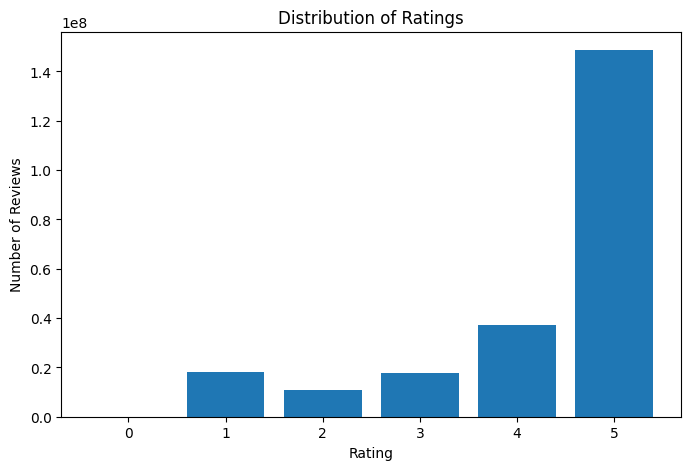

In [ ]:
#plot the skewness of the ratings distribution using a bar chart

plt.figure(figsize=(8,5))
plt.bar(ratings_distribution['rating'], ratings_distribution['count'])
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.xticks([0,1,2,3,4,5])
plt.show()

rating_skewness = -1.562
- Negative skew confirms that ratings cluster toward the high end, with a long tail on the lower side.
	
- Insight: Most products get good reviews, a few low ratings exist, which confirms a strong positive bias in the dataset, which is common in large scale e-commerce review platforms.

### Temporal Analysis

In [ ]:
# Check review per year
yearly_review = con.execute(f"""SELECT
    YEAR(TO_TIMESTAMP(unixReviewTime)) AS review_year,
    COUNT(*) AS reviews_count
FROM "{FILE}"
GROUP BY review_year
ORDER BY review_year;
""").fetchdf()

yearly_review

,review_year,reviews_count
0,1996,39
1,1997,14030
2,1998,77736
3,1999,182461
4,2000,577094
5,2001,550462
6,2002,566842
7,2003,598262
8,2004,697177
9,2005,962011


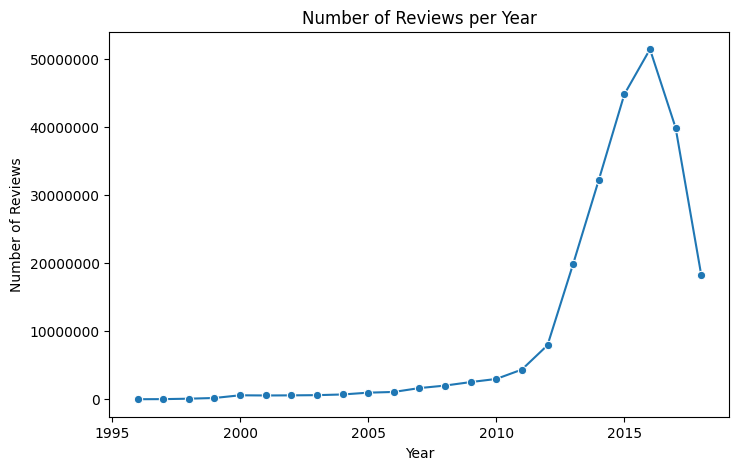

In [ ]:

plt.figure(figsize=(8,5))
sns.lineplot(x='review_year', y='reviews_count', data= yearly_review, marker='o')
plt.title('Number of Reviews per Year')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')

#disable scientific notation
plt.ticklabel_format(style='plain', axis='y')
plt.show()

The temporal analysis reveals a gradual increase in review activity from the late 1990s, followed by increased growth between 2006 and 2012.

A sharp increase occurs between 2013 and 2016, reflecting the large scale adoption of e-commerce and increased reliance on online reviews.

The decline observed in the final year likely reflects data collection ending mid year rather than a genuine reduction in platform activity.

## product popularority analysis

In [ ]:
unique_product = con.execute(f"""SELECT COUNT(DISTINCT asin) AS unique_products
FROM "{FILE}";
""").fetchdf()

unique_product

,unique_products
0,15167257


The dataset contains 15.17 million unique products, indicating broad marketplace coverage. 

Given 233 million total reviews, the average number of reviews per product is approximately 15.

However, review activity is unevenly distributed, with a small number  of products receiving high engagement.

In [ ]:
reviews_per_product = con.execute(f"""SELECT asin, COUNT(*) AS reviews_per_product
FROM "{FILE}"
GROUP BY asin
ORDER BY reviews_per_product DESC
LIMIT 50;
""").fetchdf()

reviews_per_product

,asin,reviews_per_product
0,038568231X,58150
1,0297859382,44956
2,0007420412,44381
3,0141353678,37783
4,0312577222,36620
5,0099911701,33676
6,B000X1MX7E,32495
7,0553418025,30297
8,B010OYASRG,28539
9,B00CYQP3AK,28304



Although the dataset contains over 15 million unique products, review activity is highly concentrated. The top products receive over 50,000 reviews, while the average number of reviews per product is approximately 15. This indicates a strong long tail distribution, where a small subset of products dominates user engagement.

- That ASIN of the highest reviewed product corresponds to The Girl on the Train by Paula Hawkins.

Rating: 4.1/5 stars (based on approximately 490,000+ ratings on amazon)

- second highest reviewed product corresponds to Gone Girl by Gillian Flynn.

Rating: 4.0–4.1/5 stars (based on 160,000+ ratings on Amazon)







In [ ]:
review_dimension = con.execute(f"""SELECT
    COUNT(*) FILTER (WHERE review_count = 1) AS one_review_products,
    COUNT(*) FILTER (WHERE review_count BETWEEN 2 AND 5) AS low_review_products,
    COUNT(*) FILTER (WHERE review_count > 1000) AS high_review_products
FROM (
    SELECT asin, COUNT(*) AS review_count
    FROM "{FILE}"
    GROUP BY asin
) t;
""").fetchdf()

review_dimension

,one_review_products,low_review_products,high_review_products
0,5767846,5176327,20118


Most products have very few reviews:
combining the low volume products
- 5,767,846  (1 review) + 5,176,327 (2–5 reviews)
= 10,944,173 products

- 10,944,173 / 15,167,257(amount of products) = 0.72157 (approximately 72%)
This mean around 72% of all products have 5 or fewer reviews.

very few products are highly reviewed:
- which is 20,118 products
20,118 / 15,167,257 = 0.00132 (approximately  0.0013%)

- This means around 0.0013% of the products are heavily reveiwed.

## Code References and Inspiration

Some code patterns used in this notebook were inspired by official documentation and publicly available learning resources. These include examples of data exploration, data manipulation, and visualization using Python data science libraries.

References include:
- Matplotlib Documentation: https://matplotlib.org/stable/index.html

- Seaborn Documentation: https://seaborn.pydata.org/

- DuckDB Documentation: https://duckdb.org/docs/

These resources were used as guidance when implementing data exploration and visualization steps.

### AI Assistance

ChatGPT 5.0 was used occasionally to assist with debugging and clarifying Python and SQL syntax. All analysis, implementation, and interpretation were completed by the team members.